<a href="https://colab.research.google.com/github/Janardan-thapaliya/LangGraph_workflows/blob/main/ChatBot_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q langgraph langchain langchain_openai langchain_core python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.4/542.4 kB 4.2 MB/s eta 0:00:00


In [ ]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_openai import ChatOpenAI

In [ ]:
model_llm = ChatOpenAI()

In [ ]:
from langgraph.graph.message import add_messages #Works like operator.add to add messages to list but more optimized for chats
#State

class ChatState(TypedDict):

  messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
#Define chat node function
def chat_node(state: ChatState) -> ChatState:

  #Get messages from the state
  messages = state['messages']

  #Create prompt for LLM


  #Send prompt to LLM
  response = model_llm.invoke(messages)


  #update state with response
  return {'messages': [response]}

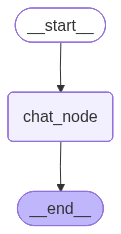

In [ ]:
#Build Graph
graph = StateGraph(ChatState)

#Add node to graph
graph.add_node('chat_node', chat_node)

#Add edges to graph
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

#Compile graph
g = graph.compile()
g

In [ ]:
#Execute Graph

#Initial State
initial_state = {
    'messages': [HumanMessage(content='Hello, how are you?')]
}


#Final State
final_state = g.invoke(initial_state)

#Print State
print(final_state)

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='8e829f85-f1c2-4dc3-a46a-73932aab923b'), AIMessage(content="Hello! I'm just a computer program, so I don't have feelings, but I'm here to assist you. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 13, 'total_tokens': 44, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-Da5QxfZzpUsvpsndtgtHAEPdKfrc6', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ddad7-bfe9-7d11-901a-7a39bfbff8d9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 31, 'total_tokens'

**Basic Chatbot skeleton is ready**

Now we try to make Chatbot like feel with While Loop

In [ ]:
while True:

  user_message = input('User: ')

  if user_message.strip().lower() in ['quit', 'exit', 'bye']:
    break

  response = g.invoke({'messages': [HumanMessage(content=user_message)]})

  print('AI:', response['messages'][-1].content)

User: Hello!
AI: Hello! How can I assist you today?
User: I want to learn LangGraph in 7 days. What resource should I use?
AI: To learn LangGraph in 7 days, it is recommended to start with the official LangGraph website, which provides documentation, tutorials, and examples. Additionally, there are online courses and tutorials available on platforms like Udemy, Coursera, and YouTube that can help you learn LangGraph quickly and efficiently. It is also helpful to join online communities and forums related to LangGraph to connect with other learners and ask questions. Practice regularly and try to build projects using LangGraph to reinforce your learning.
User: Bye


**Although this creates a feel of chatbots, each response is new call to LLM and doesn't have memory of previous message.**

This is because each time an invoke function is called, all previous state gets cleared clean and we start fresh anew.

That's why we need Persistence.

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver #Add for persistence

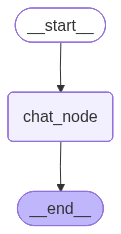

In [ ]:
#create checkpointer before adding graph
checkpointer = MemorySaver()

#Build Graph
graph = StateGraph(ChatState)

#Add node to graph
graph.add_node('chat_node', chat_node)

#Add edges to graph
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

#Compile graph
g = graph.compile(checkpointer=checkpointer)
g

In [ ]:
thread_id = '1' #To identify the unique chat

while True:

  user_message = input('User: ')

  if user_message.strip().lower() in ['quit', 'exit', 'bye']:
    break

  config = {'configurable': {'thread_id': thread_id}} #Add this to parse unique id

  response = g.invoke({'messages': [HumanMessage(content=user_message)]}, config=config) #Pass config while invoking to remember the thread memory

  print('AI:', response['messages'][-1].content)

User: Hi, I am Tom.
AI: Hi Tom, nice to meet you. How can I assist you today?
User: What is my name?
AI: Your name is Tom.
User: Bye


In [ ]:
g.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='Hi, I am Tom.', additional_kwargs={}, response_metadata={}, id='d1fe47e7-79c2-49a9-8465-96250c328642'), AIMessage(content='Hi Tom, nice to meet you. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 13, 'total_tokens': 28, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DaO3KuO0LxOucRbL3yxw6Nm5LgtrC', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ddf1b-d84a-7201-afed-2c5e3b3fa1f9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 15, 'total_tokens': 28, 'input_token_details': {'audio': 0, 'cach

**Persistence in LangGraph**

Save or restore the state of workflow over time.

LangGraph's fundamental working principle is to allow any node get access to State when workflow is still running. As soon as it hits END node, the state is wiped from the RAM and will only stay in it final form if it is saved in a variable (but only the last state and not intermediate states).

Persistence allows to store and access each intermediate states of the workflow and it can be accessed over multiple workflow loops or iterations.

This becomes a feature called Fault Tolerance because if it crashes, we can retrigger the workflow without statring over but from that last saved state.

**Workflow: Topic --> Generate joke --> Explain joke --> END**

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver #It saves in RAM - only used for demo. In real life, DB is used to store

In [ ]:
llm = ChatOpenAI()

In [ ]:
class JokeState(TypedDict):

  topic: str
  joke: str
  explanation: str

In [ ]:
#Create function for node function to generate joke
def generate_joke(state: JokeState) -> JokeState:
  #get topic from the state
  topic = state['topic']

  #Create prompt to generate joke on topic
  prompt = f'Generate a joke on the topic: {topic}'

  #call LLM to get the joke
  response = llm.invoke(prompt).content

  #update state with joke
  return {'joke': response}

In [ ]:
#Create function for node function to explain the joke
def explain_joke(state: JokeState) -> JokeState:
  #get joke from the state
  joke = state['joke']

  #Create prompt to explain the joke
  prompt = f'Write an explanation for the joke: {joke}'

  #call LLM to get response
  response = llm.invoke(prompt).content

  #update state with explanation
  return {'explanation': response}

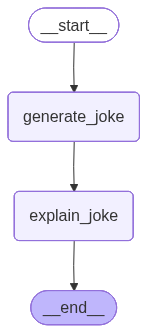

In [ ]:
#Add Checkpointer
checkpointer = MemorySaver()

#Build graph
graph = StateGraph(JokeState)

#Add node
graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

#Add edge
graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

#Compile graph
joke = graph.compile(checkpointer=checkpointer)
joke

In [ ]:
config1 = {'configurable': {'thread_id': '1'}}
joke.invoke({'topic': 'Lithuanian Univerity'}, config=config1)

{'topic': 'Lithuanian Univerity',
 'joke': 'Why did the Lithuanian university hire a comedian as their new dean? \nBecause they wanted someone to bring laughter to the lecture halls instead of just boring lectures!',
 'explanation': 'This joke plays on the stereotype that university lectures can be dry and boring. By hiring a comedian as the new dean, the university hopes to inject some humor and excitement into the classroom, making the learning experience more enjoyable for the students. The punchline suggests that the university values laughter and entertainment in addition to academic rigor.'}

In [ ]:
joke.get_state(config=config1)

StateSnapshot(values={'topic': 'Lithuanian Univerity', 'joke': 'Why did the Lithuanian university hire a comedian as their new dean? \nBecause they wanted someone to bring laughter to the lecture halls instead of just boring lectures!', 'explanation': 'This joke plays on the stereotype that university lectures can be dry and boring. By hiring a comedian as the new dean, the university hopes to inject some humor and excitement into the classroom, making the learning experience more enjoyable for the students. The punchline suggests that the university values laughter and entertainment in addition to academic rigor.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bc3-b81c-65bf-8006-6d1730c5a368'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-04-30T17:44:26.809630+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bc3-a44a-63c9-8005-580379e9abf2'}}, tasks=(), i

In [ ]:
list(joke.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'Lithuanian Univerity', 'joke': 'Why did the Lithuanian university hire a comedian as their new dean? \nBecause they wanted someone to bring laughter to the lecture halls instead of just boring lectures!', 'explanation': 'This joke plays on the stereotype that university lectures can be dry and boring. By hiring a comedian as the new dean, the university hopes to inject some humor and excitement into the classroom, making the learning experience more enjoyable for the students. The punchline suggests that the university values laughter and entertainment in addition to academic rigor.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bc3-b81c-65bf-8006-6d1730c5a368'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-04-30T17:44:26.809630+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bc3-a44a-63c9-8005-580379e9abf2'}}, tasks=(), 

In [ ]:
config2 = {'configurable': {'thread_id': '2'}}
joke.invoke({'topic': 'AI System Architect'}, config=config2)

{'topic': 'AI System Architect',
 'joke': "Why did the AI System Architect go to therapy? Because it couldn't handle all the unsolicited advice from Siri and Alexa!",
 'explanation': 'This joke plays on the idea that AI system architects are responsible for designing and creating artificial intelligence systems like Siri and Alexa. The punchline suggests that the AI system architect went to therapy because they were struggling to cope with all the unsolicited advice and constant input from the AI systems they had created. It humorously portrays a scenario in which the architect is overwhelmed by their own creations, highlighting the irony of someone who is supposed to be in control of technology being bombarded with unwanted suggestions from it.'}

**Applying Fault Tolerance**

In [ ]:
from langgraph.checkpoint.memory import InMemorySaver
import time

In [ ]:
#define state
class CrashState(TypedDict):

  input: str
  step1: str
  step2: str
  step3: str

In [ ]:
#Define steps to emulate workflow
def step1(state: CrashState) -> CrashState:
  input = state['input']
  print("Step 1 Executed")
  return {'step1': 'done', 'input': input}

def step2(state: CrashState) -> CrashState:
  print("Step 2 hanging..... Manually interrupt to simulate crash")
  time.sleep(30)   #Wait 30 seconds to provide time for interrupt simulation
  return {'step2': 'done'}

def step3(state: CrashState) -> CrashState:
  print("Step 3 Executed")
  return {'step3': 'done'}

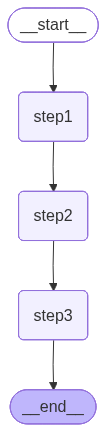

In [ ]:
#Build Graph
graph = StateGraph(CrashState)

checkpointer = InMemorySaver()

#Add nodes and edges
graph.add_node('step1', step1)
graph.add_node('step2', step2)
graph.add_node('step3', step3)

graph.add_edge(START, 'step1')
graph.add_edge('step1', 'step2')
graph.add_edge('step2', 'step3')
graph.add_edge('step3', END)

#Compile graph
workflow = graph.compile(checkpointer=checkpointer)
workflow

In [ ]:
try:
  print("Running graph....")
  workflow.invoke({'input': 'start'}, config={'configurable': {'thread_id': '1'}})
except KeyboardInterrupt:
  print("Crash Simulated. (Manual Interruption)")

Running graph....
Step 1 Executed
Step 2 hanging..... Manually interrupt to simulate crash
Crash Simulated. (Manual Interruption)


In [ ]:
workflow.get_state(config={'configurable': {'thread_id': '1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bf5-3a9e-6998-8001-15d796150b30'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-30T18:06:35.828251+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bf5-3a99-63cf-8000-fada8da28e46'}}, tasks=(PregelTask(id='085053f0-ad55-9150-c792-6cf30afc0e48', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [ ]:
#The state is read from the bottom up. The first is the last StateSnapshot in the list.
list(workflow.get_state_history(config={'configurable': {'thread_id': '1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bf5-3a9e-6998-8001-15d796150b30'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-30T18:06:35.828251+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bf5-3a99-63cf-8000-fada8da28e46'}}, tasks=(PregelTask(id='085053f0-ad55-9150-c792-6cf30afc0e48', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'start'}, next=('step1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bf5-3a99-63cf-8000-fada8da28e46'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-30T18:06:35.826057+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bf5-3a96-691

In [ ]:
#Resume to apply fault-tolerance
Final_state = workflow.invoke(None, config={'configurable': {'thread_id': '1'}})  #Initial state value is not provided, instead None is passed to resume with same thread_id
print('\n Final State:', Final_state)

Step 2 hanging..... Manually interrupt to simulate crash
Step 3 Executed

 Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}


In [ ]:
workflow.get_state(config={'configurable': {'thread_id': '1'}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bfe-f4cb-6bd6-8003-716a717f768b'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-30T18:10:56.942156+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bfe-f4c8-60c0-8002-580b7b7324b1'}}, tasks=(), interrupts=())

In [ ]:
#The next shows which node will be run next, empty means finished executing the graph
list(workflow.get_state_history(config={'configurable': {'thread_id': '1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bfe-f4cb-6bd6-8003-716a717f768b'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-30T18:10:56.942156+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bfe-f4c8-60c0-8002-580b7b7324b1'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bfe-f4c8-60c0-8002-580b7b7324b1'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-30T18:10:56.940601+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f144bf5-3a9e-6998-8001-15d796150b30'}}, tasks=(PregelTask(id='df321b74-2d40-133b-4a7b-c400874bfd7f', name='st

**Human in the Loop**

**Time Travel**

The persistence allows us the ability to go to a particular node in particular time and replay the workflow. Especially used for Debugging purposes.

It is done by using the checkpoint ID of our targeted StateSnapshot from the get_state_history.

In [ ]:
#For the same generate joke workflow
joke_config = {'configurable': {'thread_id': '10'}}
joke.invoke({'topic': 'Pizza'}, config=joke_config)

{'topic': 'Pizza',
 'joke': "Why did the pizza maker go to therapy? Because he couldn't stop topping himself!",
 'explanation': 'This joke plays on the double meaning of the phrase "topping himself." In the context of making pizza, topping refers to adding ingredients to the pizza, but "topping himself" can also mean someone continuously trying to outdo or impress themselves. In this case, the pizza maker is unable to stop adding toppings to his pizzas, so he jokingly goes to therapy for help with his topping addiction.'}

In [ ]:
list(joke.get_state_history(config=joke_config))

[StateSnapshot(values={'topic': 'Pizza', 'joke': "Why did the pizza maker go to therapy? Because he couldn't stop topping himself!", 'explanation': 'This joke plays on the double meaning of the phrase "topping himself." In the context of making pizza, topping refers to adding ingredients to the pizza, but "topping himself" can also mean someone continuously trying to outdo or impress themselves. In this case, the pizza maker is unable to stop adding toppings to his pizzas, so he jokingly goes to therapy for help with his topping addiction.'}, next=(), config={'configurable': {'thread_id': '10', 'checkpoint_ns': '', 'checkpoint_id': '1f144c1d-e4f7-667e-8002-6d2d0c463e19'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-30T18:24:47.432232+00:00', parent_config={'configurable': {'thread_id': '10', 'checkpoint_ns': '', 'checkpoint_id': '1f144c1d-d5ec-6a06-8001-6de09aa862de'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'Pizza', 'joke': "Why did t

In [ ]:
#the checkpoint_id before entering Generate joke node is 1f144c1d-c273-6993-8000-452db803ef39
joke.get_state({"configurable": {"thread_id": "10", "checkpoint_id": "1f144c1d-c273-6993-8000-452db803ef39"}})

StateSnapshot(values={'topic': 'Pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '10', 'checkpoint_id': '1f144c1d-c273-6993-8000-452db803ef39'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-04-30T18:24:43.813093+00:00', parent_config={'configurable': {'thread_id': '10', 'checkpoint_ns': '', 'checkpoint_id': '1f144c1d-c26d-6e75-bfff-3d6d3e475a7e'}}, tasks=(PregelTask(id='91e595ce-842a-f400-dcc0-f94e344e7237', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': "Why did the pizza maker go to therapy? Because he couldn't stop topping himself!"}),), interrupts=())

In [ ]:
#Now, to re-execute the flow from this point so that new joke can be generated, we pass None instead of topic to resume from that checkpoint_id
joke.invoke(None, {"configurable": {"thread_id": "10", "checkpoint_id": "1f144c1d-c273-6993-8000-452db803ef39"}})

{'topic': 'Pizza',
 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling a little crusty!',
 'explanation': 'This joke plays on the double meaning of the word "crusty". In one sense, crusty can refer to the outer edge of a pizza, which is typically crispy and firm. In the other sense, crusty can mean someone who is in a bad or grumpy mood. So, when the joke says the pizza went to the doctor because it was feeling a little crusty, it\'s implying that the pizza was feeling unwell or in a bad mood, rather than actually having a physical illness.'}

In [ ]:
list(joke.get_state_history(joke_config))

[StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling a little crusty!', 'explanation': 'This joke plays on the double meaning of the word "crusty". In one sense, crusty can refer to the outer edge of a pizza, which is typically crispy and firm. In the other sense, crusty can mean someone who is in a bad or grumpy mood. So, when the joke says the pizza went to the doctor because it was feeling a little crusty, it\'s implying that the pizza was feeling unwell or in a bad mood, rather than actually having a physical illness.'}, next=(), config={'configurable': {'thread_id': '10', 'checkpoint_ns': '', 'checkpoint_id': '1f144c2a-c338-6d2d-8003-1ca382077124'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-30T18:30:32.859962+00:00', parent_config={'configurable': {'thread_id': '10', 'checkpoint_ns': '', 'checkpoint_id': '1f144c2a-ab7d-61a1-8002-8bd7acd9a757'}}, tasks=(), interrupts=()),
 StateSnapshot(value

**Updating State**

In [ ]:
joke.update_state({"configurable": {"thread_id": "10", "checkpoint_id": "1f144c1d-c273-6993-8000-452db803ef39"}, 'checkpoint_ns': '',}, {'topic': 'Donkey'})

{'configurable': {'thread_id': '10',
  'checkpoint_ns': '',
  'checkpoint_id': '1f144c3b-bc79-6bcc-8001-c3d2d18c86c9'}}

In [ ]:
list(joke.get_state_history(joke_config))

[StateSnapshot(values={'topic': 'Donkey'}, next=('generate_joke',), config={'configurable': {'thread_id': '10', 'checkpoint_ns': '', 'checkpoint_id': '1f144c3b-bc79-6bcc-8001-c3d2d18c86c9'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-04-30T18:38:08.492830+00:00', parent_config={'configurable': {'thread_id': '10', 'checkpoint_ns': '', 'checkpoint_id': '1f144c1d-c273-6993-8000-452db803ef39'}}, tasks=(PregelTask(id='4789741d-6722-25ac-a343-e759187e0c40', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'Pizza', 'joke': 'Why did the pizza go to the doctor?\nBecause it was feeling a little crusty!', 'explanation': 'This joke plays on the double meaning of the word "crusty". In one sense, crusty can refer to the outer edge of a pizza, which is typically crispy and firm. In the other sense, crusty can mean someone who is in a bad or grumpy mood. 

In [ ]:
joke.invoke(None, {"configurable": {"thread_id": "10", "checkpoint_id": "1f144c3b-bc79-6bcc-8001-c3d2d18c86c9"}})

{'topic': 'Donkey',
 'joke': 'Why did the donkey go to school?\n\nBecause he wanted to be a little "bray"-nsiac!',
 'explanation': 'This joke plays on the similarity between the word "brains" and the sound that a donkey makes, which is called a "bray". By saying the donkey wanted to be a "bray"-nsiac, it is implying that the donkey wanted to be smart and learn by going to school. It\'s a play on words that combines the donkey\'s characteristic sound with the idea of wanting to increase intelligence by going to school.'}

**Streaming in LangGraph**

Instead of graph.invoke, we use graph.stream.

It returns a generator object is a special type of iterator that allows generating outputs on the fly, one at a time, using yield keyword instead of return.

In [ ]:
stream = chatbot.stream{
    {'messages': [HumanMessage(content='Hello, how are you?')]},  #Input state - initial
    config={'configurable': {'thread_id': '1'}},  #Config, just like invoke for persistence
    stream_mode='messages'    #Multiple modes are available - values, updates, custom, messages etc - LLM response is sent through messages
}

print(type(stream))  #To check if we have received generator object

#This generator object always has two components - message_chunk and metadata so we need to access them while iterating
for message_chunk, metadata in stream:
  if message_chunk.content:   #Checking if we have received response
    print(message_chunk.content, end=" ", flush=True)  #Printing part by part

**Multiple sessions or threads in chat**

Each session ID will be stored and it can be accessed later.



In [ ]:
response = chatbot.invoke(
    {'messages': [HumanMessage(content='Hello, how are you?')]},
    config={'configurable': {'thread_id': '1'}}
)

chatnot.get_state(config={'configurable': {'thread_id': '1'}}).values['messages'] #To extract all messages from the thread ID

In [ ]:
!pip install -q langgraph langchain langchain_openai python-dotenv langchain_community langchain_core ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 39.8 MB/s eta 0:00:00


In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, BaseMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

In [ ]:
load_dotenv()

True

In [ ]:
llm = ChatOpenAI()

In [ ]:
#Tools
search_tool = DuckDuckGoSearchRun(region='us-en')

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
  """
  Perform a basic arithmetic operation on two numbers.
  Supported operations: add, sub, mul, div
  """
  try:
    if operation == 'add':
      result = first_num + second_num
    elif operation == 'sub':
      result = first_num - second_num
    elif operation == 'mul':
      result = first_num * second_num
    elif operation == 'div':
      if second_num == 0:
        return {'error': 'Cannot divide by zero'}
      result = first_num / second_num
    else:
      return {'error': f"Invalid operation: '{operation}'"}

    return {'first_num': first_num, 'second_num': second_num, 'operation': operation, 'result': result}
  except Exception as e:
    return {'error': str(e)}


@tool
def get_stock_price(symbol: str) -> dict:
  """
  Fetch the current stock price for a given symbol (eg. 'AAPL', 'TSLA')
  using Alpha Vantage with API key in the URL.
  """
  url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol='{symbol}'&apikey=" #Add your API key, its free
  r = requests.get(url)
  return r.json()

In [ ]:
#Make tool list
tools = [get_stock_price, search_tool, calculator]

#Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [ ]:
#State
class ChatState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
#Graph nodes
def chat_node(state: ChatState) -> ChatState:
  """
  LLM node that may answer ot request a tool call.
  """
  #Get messages from the state
  messages = state['messages']

  #invoke model that is tool aware
  response = llm_with_tools.invoke(messages)

  #update state with response
  return {'messages': [response]}

tools = ToolNode(tools)  #Execute tool calls

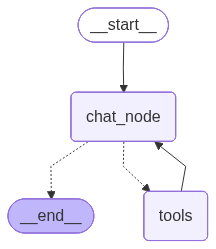

In [ ]:
#Graph Structure
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tools', tools)

#Add edges
graph.add_edge(START, 'chat_node')

graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()
chatbot


In [ ]:
#Regular chat
out = chatbot.invoke({'messages': [HumanMessage(content='Hello, how are you?')]})
out['messages'][-1].content

"Hello! I'm here and ready to assist you. How can I help you today?"

In [ ]:
#Chat requiring tool
out = chatbot.invoke({'messages': [HumanMessage(content='What is the product of 5 and 6?')]})
out['messages'][-1].content

'The product of 5 and 6 is 30.'

In [ ]:
#Chat requiring multi-tool usage
out = chatbot.invoke({'messages': [HumanMessage(content='What is the stock price of Apple and how much can I purchase with $1000?')]})
out['messages'][-1].content

'With $1000, you can purchase approximately 3.69 shares of Apple (AAPL) at the current stock price of $271.06.'